# NYC Parks — Budget vs. Spending Analysis and Forecast
**Department of Parks and Recreation, FY2017–FY2026**

1. Clean the budget-vs-spending data (FY2017 onward) and drop the incomplete fiscal year.
2. Compare adopted budget, modified budget, and actual spending — by year and by budget code.
3. **Model 1 (ARIMAX):** forecast total agency spending for FY2027–FY2029.
4. **Model 2 (Regression):** predict next-year spending for each budget code.
5. **Accuracy table** with R² and accuracy % for every model.
6. **Statistics:** descriptive stats, stationarity test, model coefficients and p-values, error metrics.

Files used: `ParksBudget_vs_Spending.csv` (main), `ParksSpending.csv` and `ParksBudget.csv` (budget-code names).

In [1]:
import warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)

# Folder containing the CSV files ("" = same folder as this notebook)
DATA_DIR = ""

M = 1_000_000  # helper: show dollars in millions

## 1. Load and clean the data

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, "ParksBudget_vs_Spending.csv"), dtype={"Budget Code": str})
df = df[df["Year"] >= 2017].copy()

# Is every fiscal year complete? Compare what was spent against the modified budget.
completeness = df.groupby("Year")[["Modified_Budget", "Actual_Spending"]].sum() / M
completeness["Spent_%_of_Budget"] = (completeness["Actual_Spending"] / completeness["Modified_Budget"] * 100).round(1)
print("Totals in $ millions:")
print(completeness.round(1))

Totals in $ millions:
      Modified_Budget  Actual_Spending  Spent_%_of_Budget
Year                                                     
2017           1075.0           1022.2               95.1
2018           1107.5           1009.9               91.2
2019           1140.1           1062.7               93.2
2020           1150.7           1071.2               93.1
2021           1096.6           1001.0               91.3
2022           1245.7           1097.5               88.1
2023           1271.3           1142.1               89.8
2024           1275.8           1191.5               93.4
2025           1310.4           1250.6               95.4
2026           1447.5           1295.8               89.5
2027           1430.9            212.2               14.8


In [3]:
# FY2027 has only a few weeks of spending recorded, so it cannot be compared to a full year.
# Keep FY2017-FY2026 for all analysis and training; FY2027 budgets are kept separately for prediction.
fy2027 = df[df["Year"] == 2027].copy()
df = df[df["Year"] <= 2026].copy()

print(f"Rows kept (FY2017-FY2026): {len(df):,}")
print(f"Budget codes: {df['Budget Code'].nunique():,}")

Rows kept (FY2017-FY2026): 10,608
Budget codes: 1,172


In [4]:
# Add a readable name for each budget code.
# The spending file writes some codes as "6600 (FORESTRY)" - we extract those names.
sp_codes = pd.read_csv(os.path.join(DATA_DIR, "ParksSpending.csv"), usecols=["Budget Code"], dtype=str)
code_name = {}
for raw in sp_codes["Budget Code"].dropna().unique():
    if "(" in raw:
        code_part, name_part = raw.split("(", 1)
        code_name.setdefault(code_part.strip(), name_part.rstrip(")").strip())

# For codes with no name, fall back to their largest expense category (mostly payroll codes).
budget_detail = pd.read_csv(os.path.join(DATA_DIR, "ParksBudget.csv"), dtype={"Budget Code": str},
                            usecols=["Budget Code", "Expense Category", "Modified"])
top_cat = (budget_detail.groupby(["Budget Code", "Expense Category"])["Modified"].sum()
           .reset_index().sort_values("Modified", ascending=False)
           .drop_duplicates("Budget Code").set_index("Budget Code")["Expense Category"])

ACRONYMS = {"Nyc": "NYC", "Si": "SI", "Bpd": "BPD", "Dep": "DEP", "Cc": "CC", "Dot": "DOT", "Dpr": "DPR"}
tidy = lambda t: " ".join(ACRONYMS.get(w, w) for w in t.title().split())

def name_of(code):
    if code in code_name:
        return tidy(code_name[code])
    if code in top_cat.index:
        return tidy(top_cat[code]) + " (unnamed code)"
    return "Unknown"

for frame in (df, fy2027):
    frame["Code_Name"] = frame["Budget Code"].map(name_of)

named = df["Budget Code"].map(lambda x: x in code_name)
print(f"{named.sum():,} of {len(df):,} rows got a real budget-code name; "
      f"that covers {df.loc[named, 'Actual_Spending'].sum() / df['Actual_Spending'].sum():.0%} of all dollars spent.")
print("Codes with no name in the data are labelled with their main expense category instead.")

2,788 of 10,608 rows got a real budget-code name; that covers 48% of all dollars spent.
Codes with no name in the data are labelled with their main expense category instead.


## 2. Budget vs. actual spending by year

In [5]:
yearly = df.groupby("Year")[["Adopted_Budget", "Modified_Budget", "Actual_Spending"]].sum() / M
yearly["Unspent_$M"] = yearly["Modified_Budget"] - yearly["Actual_Spending"]
yearly["Utilization_%"] = yearly["Actual_Spending"] / yearly["Modified_Budget"] * 100
yearly.round(1)

,Adopted_Budget,Modified_Budget,Actual_Spending,Unspent_$M,Utilization_%
Year,,,,,
2017,1012.8,1075.0,1022.2,52.8,95.1
2018,1063.7,1107.5,1009.9,97.6,91.2
2019,1068.1,1140.1,1062.7,77.4,93.2
2020,1174.4,1150.7,1071.2,79.4,93.1
2021,1006.1,1096.6,1001.0,95.6,91.3
2022,1239.8,1245.7,1097.5,148.2,88.1
2023,1248.4,1271.3,1142.1,129.2,89.8
2024,1276.4,1275.8,1191.5,84.4,93.4
2025,1236.1,1310.4,1250.6,59.7,95.4


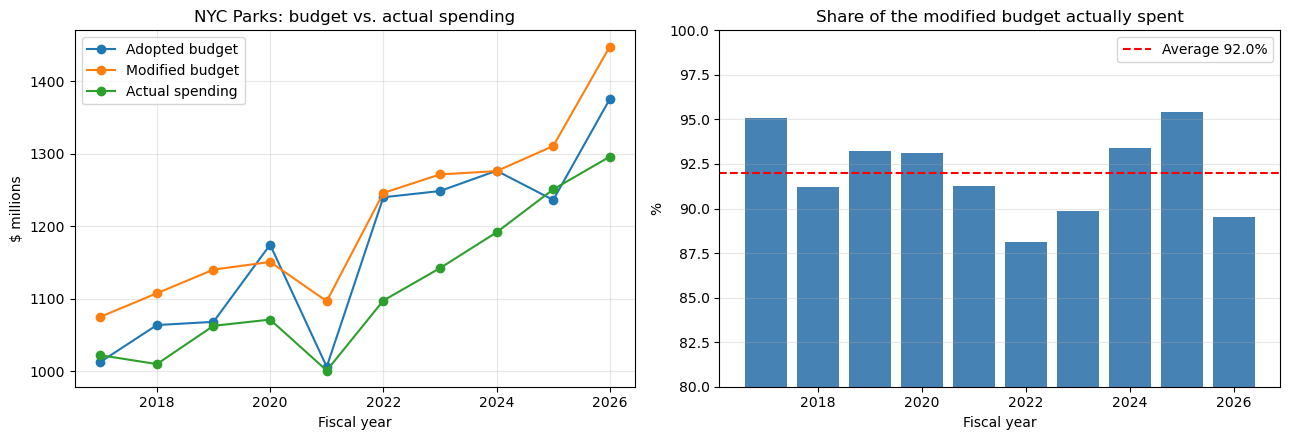

Parks spends 92.0% of its modified budget on average, leaving $98M unspent per year.


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(yearly.index, yearly["Adopted_Budget"], marker="o", label="Adopted budget")
ax[0].plot(yearly.index, yearly["Modified_Budget"], marker="o", label="Modified budget")
ax[0].plot(yearly.index, yearly["Actual_Spending"], marker="o", label="Actual spending")
ax[0].set_title("NYC Parks: budget vs. actual spending")
ax[0].set_xlabel("Fiscal year"); ax[0].set_ylabel("$ millions"); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].bar(yearly.index, yearly["Utilization_%"], color="steelblue")
ax[1].axhline(yearly["Utilization_%"].mean(), color="red", ls="--",
              label=f"Average {yearly['Utilization_%'].mean():.1f}%")
ax[1].set_ylim(80, 100)
ax[1].set_title("Share of the modified budget actually spent")
ax[1].set_xlabel("Fiscal year"); ax[1].set_ylabel("%"); ax[1].legend(); ax[1].grid(alpha=.3, axis="y")

plt.tight_layout(); plt.show()

print(f"Parks spends {yearly['Utilization_%'].mean():.1f}% of its modified budget on average, "
      f"leaving ${yearly['Unspent_$M'].mean():.0f}M unspent per year.")

In [7]:
# Where the money goes: the 10 largest budget codes in FY2026
top10 = (df[df["Year"] == 2026]
         .nlargest(10, "Actual_Spending")
         .assign(Modified_M=lambda d: d["Modified_Budget"] / M,
                 Spent_M=lambda d: d["Actual_Spending"] / M,
                 Used_pct=lambda d: d["Actual_Spending"] / d["Modified_Budget"] * 100)
         [["Budget Code", "Code_Name", "Modified_M", "Spent_M", "Used_pct"]])
top10.round(1).reset_index(drop=True)

,Budget Code,Code_Name,Modified_M,Spent_M,Used_pct
0,2801,Seasonal Positions (unnamed code),99.0,92.5,93.4
1,2360,Queens Boro-Wide Services,79.7,74.7,93.8
2,2320,Brooklyn Boro-Wide Services,81.8,71.6,87.6
3,2340,Manhattan Boro-Wide Services,78.8,67.2,85.3
4,0110,Full Year Positions (unnamed code),70.5,54.7,77.5
5,IMP2,Full Year Positions (unnamed code),49.3,54.0,109.6
6,3808,Full Year Positions (unnamed code),57.5,51.8,90.1
7,2300,Bronx Boro-Wide Services,60.7,51.8,85.3
8,HTS2,Full Year Positions (unnamed code),53.1,41.2,77.6
9,2295,Full Year Positions (unnamed code),3.1,36.8,1194.3


## 3. Model 1 — forecasting total agency spending

Total actual spending per fiscal year (10 points, FY2017–FY2026).

We test plain ARIMA against **ARIMAX**, which adds one outside variable: that year's **adopted budget**.
The adopted budget is published before the fiscal year starts, so using it is not cheating — it is
information a budget office really has in advance.

**How the models are tested:** train on FY2017–FY2021, predict FY2022; add FY2022 and predict FY2023;
and so on through FY2026. That gives 5 one-year-ahead predictions the model never saw during training.

**Accuracy % = 100 − MAPE** (mean absolute percentage error).

In [8]:
totals = df.groupby("Year")[["Adopted_Budget", "Modified_Budget", "Actual_Spending"]].sum() / M
years_idx = pd.date_range("2017", periods=len(totals), freq="YS")   # ARIMA wants a dated index
series = totals["Actual_Spending"]; series.index = years_idx
adopted = totals["Adopted_Budget"]; adopted.index = years_idx
modified = totals["Modified_Budget"]; modified.index = years_idx

def validate(s, order, trend=None, exog=None, first_test=5):
    """Train on the past, predict the next year, repeat. Returns predictions and true values."""
    preds, actuals = [], []
    for cut in range(first_test, len(s)):
        ex_train = exog.iloc[:cut] if exog is not None else None
        ex_next = exog.iloc[cut:cut + 1] if exog is not None else None
        model = ARIMA(s.iloc[:cut], order=order, trend=trend, exog=ex_train).fit()
        preds.append(float(model.forecast(1, exog=ex_next).iloc[0]))
        actuals.append(float(s.iloc[cut]))
    return np.array(preds), np.array(actuals)

candidates = {
    "ARIMA(0,1,0)":                  dict(order=(0, 1, 0), trend=None),
    "ARIMA(0,1,0) + drift":          dict(order=(0, 1, 0), trend="t"),
    "ARIMA(1,1,0) + drift":          dict(order=(1, 1, 0), trend="t"),
    "ARIMAX(0,1,0) + adopted budget": dict(order=(0, 1, 0), trend="t", exog=adopted),
    "ARIMAX(1,1,0) + adopted budget": dict(order=(1, 1, 0), trend="t", exog=adopted),
}

rows = []
for label, cfg in candidates.items():
    p, a = validate(series, **cfg)
    mape = np.mean(np.abs((a - p) / a)) * 100
    rows.append({"Model": label, "R2": r2_score(a, p), "MAPE_%": mape, "Accuracy_%": 100 - mape,
                 "RMSE_$M": np.sqrt(mean_squared_error(a, p))})

arima_scores = pd.DataFrame(rows).set_index("Model").round(3)
best_label = arima_scores["Accuracy_%"].idxmax()
print(f"Best model: {best_label}")
arima_scores

Best model: ARIMAX(0,1,0) + adopted budget


,R2,MAPE_%,Accuracy_%,RMSE_$M
Model,,,,
"ARIMA(0,1,0)",0.246,5.011,94.989,62.078
"ARIMA(0,1,0) + drift",0.469,3.680,96.320,52.126
"ARIMA(1,1,0) + drift",0.199,4.914,95.086,63.985
"ARIMAX(0,1,0) + adopted budget",0.681,3.164,96.836,40.406
"ARIMAX(1,1,0) + adopted budget",0.366,3.633,96.367,56.916


In [9]:
# Year-by-year test results for the winning model
best_cfg = candidates[best_label]
pred_bt, actual_bt = validate(series, **best_cfg)
test_years = series.index.year[-len(pred_bt):]

backtest = pd.DataFrame({"Fiscal_Year": test_years,
                         "Actual_$M": actual_bt.round(1),
                         "Predicted_$M": pred_bt.round(1)})
backtest["Error_%"] = ((backtest["Predicted_$M"] - backtest["Actual_$M"]) / backtest["Actual_$M"] * 100).round(1)
backtest

,Fiscal_Year,Actual_$M,Predicted_$M,Error_%
0,2022,1097.5,1064.3,-3.0
1,2023,1142.1,1099.2,-3.8
2,2024,1191.5,1158.2,-2.8
3,2025,1250.6,1188.8,-4.9
4,2026,1295.8,1312.5,1.3


### Forecasting the modified budget too

Spending is only half the picture — the budget itself has to be projected as well. The **modified budget**
is the right one to forecast: it is what the agency is actually working with by the end of the year, and it
keeps changing all year as money is transferred between codes, so even FY2027's current figure is provisional.

The **adopted budget** is not forecast for its own sake. It only appears here because the spending model
uses it as an input, and FY2028–29 adopted budgets do not exist yet, so they have to be projected.

Both get the same one-year-ahead test as the spending model. Budgets are set by political negotiation
rather than by a smooth trend, so expect them to be harder to predict than actual spending.

In [10]:
budget_candidates = {
    "ARIMA(0,1,0)":         dict(order=(0, 1, 0), trend=None),
    "ARIMA(0,1,0) + drift": dict(order=(0, 1, 0), trend="t"),
    "ARIMA(0,1,1) + drift": dict(order=(0, 1, 1), trend="t"),
    "Linear trend":         dict(order=(0, 0, 0), trend="ct"),
}
budget_series = {"Adopted budget": adopted, "Modified budget": modified}

rows = []
for line_name, s_line in budget_series.items():
    for label, cfg in budget_candidates.items():
        p, a = validate(s_line, **cfg)
        mape = np.mean(np.abs((a - p) / a)) * 100
        rows.append({"Budget line": line_name, "Model": label, "R2": r2_score(a, p),
                     "MAPE_%": mape, "Accuracy_%": 100 - mape,
                     "RMSE_$M": np.sqrt(mean_squared_error(a, p))})

budget_scores = pd.DataFrame(rows).set_index(["Budget line", "Model"]).round(3)
best_budget = {line: budget_scores.loc[line]["Accuracy_%"].idxmax() for line in budget_series}
for line, label in best_budget.items():
    print(f"Best {line.lower()} model: {label}")
print("\nR2 is near zero or negative for every option: budgets jump with policy decisions, so no model")
print("beats simply guessing the average. The forecasts are still within about 4-5% on average.")
budget_scores

Best adopted budget model: ARIMA(0,1,1) + drift
Best modified budget model: Linear trend

R2 is near zero or negative for every option: budgets jump with policy decisions, so no model
beats simply guessing the average. The forecasts are still within about 4-5% on average.


R2  MAPE_%  Accuracy_%  RMSE_$M
Budget line     Model                                                   
Adopted budget  ARIMA(0,1,0)         -4.656   7.021      92.979  123.649
                ARIMA(0,1,0) + drift -4.571   7.442      92.558  122.725
                ARIMA(0,1,1) + drift -1.346   5.336      94.664   79.639
                Linear trend         -1.399   5.411      94.589   80.536
Modified budget ARIMA(0,1,0)         -0.668   5.289      94.711   92.622
                ARIMA(0,1,0) + drift -0.289   4.460      95.540   81.406
                ARIMA(0,1,1) + drift -0.898   5.435      94.565   98.800
                Linear trend         -0.025   4.209      95.791   72.594

In [11]:
# Refit each budget model on all 10 years and forecast FY2027-FY2029
budget_fc = {}
for line_name, s_line in budget_series.items():
    fitted = ARIMA(s_line, **budget_candidates[best_budget[line_name]]).fit()
    budget_fc[line_name] = np.array(fitted.forecast(3).values, dtype=float)

# FY2027's adopted budget is already published, so use the real number instead of the model's guess
adopted_2027 = fy2027["Adopted_Budget"].sum() / M
modified_2027_sofar = fy2027["Modified_Budget"].sum() / M
budget_fc["Adopted budget"][0] = adopted_2027

future_adopted = pd.Series(budget_fc["Adopted budget"],
                           index=pd.date_range("2027", periods=3, freq="YS"), name="Adopted_Budget")

final_arima = ARIMA(series, **best_cfg).fit()
fc = final_arima.get_forecast(3, exog=future_adopted if "exog" in best_cfg else None)
ci = fc.conf_int(alpha=0.20)   # 80% interval

forecast = pd.DataFrame({
    "Fiscal_Year": [2027, 2028, 2029],
    "Modified_Budget_$M": budget_fc["Modified budget"].round(1),
    "Forecast_Spending_$M": fc.predicted_mean.values.round(1),
    "Low_$M": ci.iloc[:, 0].values.round(1),
    "High_$M": ci.iloc[:, 1].values.round(1),
})
forecast["Predicted_Use_%"] = (forecast["Forecast_Spending_$M"] / forecast["Modified_Budget_$M"] * 100).round(1)
forecast["Unspent_$M"] = (forecast["Modified_Budget_$M"] - forecast["Forecast_Spending_$M"]).round(1)
print(f"For reference, FY2027's modified budget currently stands at ${modified_2027_sofar:,.1f}M, "
      f"but it will keep moving all year.")
forecast

For reference, FY2027's modified budget currently stands at $1,430.9M, but it will keep moving all year.


,Fiscal_Year,Modified_Budget_$M,Forecast_Spending_$M,Low_$M,High_$M,Predicted_Use_%,Unspent_$M
0,2027,1410.8,1326.8,1283.0,1370.7,94.0,84.0
1,2028,1447.0,1342.5,1280.5,1404.4,92.8,104.5
2,2029,1483.1,1371.8,1295.9,1447.7,92.5,111.3


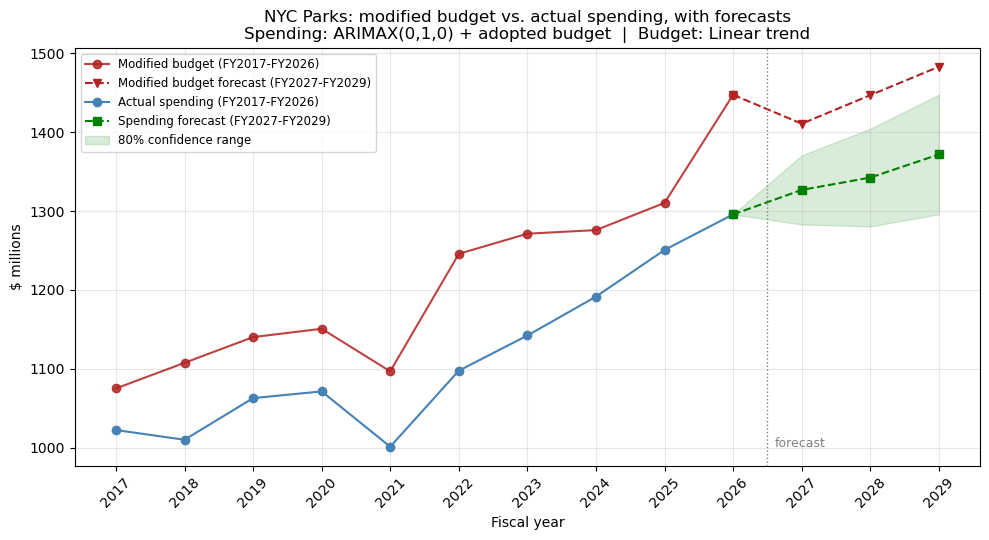

FY2027 modified budget forecast: $1,411M
FY2027 spending forecast:        $1,327M  ->  94% of the budget ($84M likely unspent)


In [12]:
# Join the history and the forecast at FY2026 so the lines connect with no gap
link_year = [series.index.year[-1]] + list(forecast["Fiscal_Year"])
link_spend = [series.iloc[-1]] + list(forecast["Forecast_Spending_$M"])
link_low = [series.iloc[-1]] + list(forecast["Low_$M"])
link_high = [series.iloc[-1]] + list(forecast["High_$M"])
link_modified = [modified.iloc[-1]] + list(forecast["Modified_Budget_$M"])

plt.figure(figsize=(10, 5.5))

# modified budget: history + forecast
plt.plot(modified.index.year, modified.values, marker="o", color="firebrick", alpha=.85,
         label="Modified budget (FY2017-FY2026)")
plt.plot(link_year, link_modified, marker="v", ls="--", color="firebrick",
         label="Modified budget forecast (FY2027-FY2029)")

# actual spending: history + forecast
plt.plot(series.index.year, series.values, marker="o", color="steelblue",
         label="Actual spending (FY2017-FY2026)")
plt.plot(link_year, link_spend, marker="s", ls="--", color="green", label="Spending forecast (FY2027-FY2029)")
plt.fill_between(link_year, link_low, link_high, color="green", alpha=.15, label="80% confidence range")

plt.axvline(2026.5, color="grey", ls=":", lw=1)
plt.text(2026.6, series.min(), "forecast", color="grey", fontsize=9)
plt.title("NYC Parks: modified budget vs. actual spending, with forecasts\n"
          f"Spending: {best_label}  |  Budget: {best_budget['Modified budget']}")
plt.xlabel("Fiscal year"); plt.ylabel("$ millions")
plt.xticks(range(2017, 2030, 1), rotation=45)
plt.legend(fontsize=8.5, loc="upper left"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

pred_2027 = forecast.loc[0, "Forecast_Spending_$M"]
budget_2027 = forecast.loc[0, "Modified_Budget_$M"]
print(f"FY2027 modified budget forecast: ${budget_2027:,.0f}M")
print(f"FY2027 spending forecast:        ${pred_2027:,.0f}M  ->  {pred_2027 / budget_2027 * 100:.0f}% of the budget "
      f"(${budget_2027 - pred_2027:,.0f}M likely unspent)")

## 4. Model 2 — predicting spending for each budget code

Model 1 gives one number for the whole agency. This model works at the budget-code level, so we can see
*which* codes are likely to over- or under-spend.

**Features:** adopted budget, modified budget, last year's actual spending, last year's modified budget,
plus post adjustments and pre-encumbered amounts (money already committed but not yet paid).
**Target:** actual spending this year.
**Split:** train on FY2018–FY2024, test on FY2025–FY2026 — future years the models never saw.

Accuracy here uses **WAPE** (total dollars missed ÷ total dollars spent) instead of MAPE, because a
$5,000 code missing by $5,000 is a 100% error but is meaningless next to a $90M code.
**Accuracy % = 100 − WAPE.**

In [13]:
panel = df.sort_values(["Budget Code", "Year"]).copy()
panel["Prev_Actual"] = panel.groupby("Budget Code")["Actual_Spending"].shift(1)
panel["Prev_Modified"] = panel.groupby("Budget Code")["Modified_Budget"].shift(1)
panel = panel.dropna(subset=["Prev_Actual"])
panel = panel[panel["Actual_Spending"] > 0]        # codes with no spending carry no signal

FEATURES = ["Adopted_Budget", "Modified_Budget", "Prev_Actual", "Prev_Modified",
            "Post_Adjustments", "Pre_Encumbered"]
TARGET = "Actual_Spending"

train = panel[panel["Year"] <= 2024]
test = panel[panel["Year"] >= 2025]
print(f"Training rows (FY2018-FY2024): {len(train):,}")
print(f"Test rows (FY2025-FY2026):     {len(test):,}")

Training rows (FY2018-FY2024): 2,052
Test rows (FY2025-FY2026):     603


In [14]:
def wape(actual, predicted):
    """Weighted absolute % error: total dollars missed / total dollars spent."""
    return np.sum(np.abs(actual - predicted)) / np.sum(actual) * 100

lin = LinearRegression().fit(train[FEATURES], train[TARGET])
rf = RandomForestRegressor(n_estimators=300, random_state=42).fit(train[FEATURES], train[TARGET])

predictions = {
    "Linear Regression": np.clip(lin.predict(test[FEATURES]), 0, None),
    "Random Forest": np.clip(rf.predict(test[FEATURES]), 0, None),
}
# Averaging the two models cancels part of each one's error
predictions["Ensemble (average of both)"] = (predictions["Linear Regression"] + predictions["Random Forest"]) / 2
# Baseline: assume every code spends exactly its modified budget (how budgeting is usually done)
predictions["Baseline: spend the whole modified budget"] = test["Modified_Budget"].values

rows = []
for label, pred in predictions.items():
    err = wape(test[TARGET].values, pred)
    rows.append({"Model": label, "R2": r2_score(test[TARGET], pred), "WAPE_%": err,
                 "Accuracy_%": 100 - err, "MAE_$": mean_absolute_error(test[TARGET], pred)})

code_scores = pd.DataFrame(rows).set_index("Model").round(3)
code_scores

,R2,WAPE_%,Accuracy_%,MAE_$
Model,,,,
Linear Regression,0.957,19.167,80.833,788761.496
Random Forest,0.966,16.543,83.457,680780.994
Ensemble (average of both),0.968,16.497,83.503,678880.166
Baseline: spend the whole modified budget,0.922,30.587,69.413,1258728.828


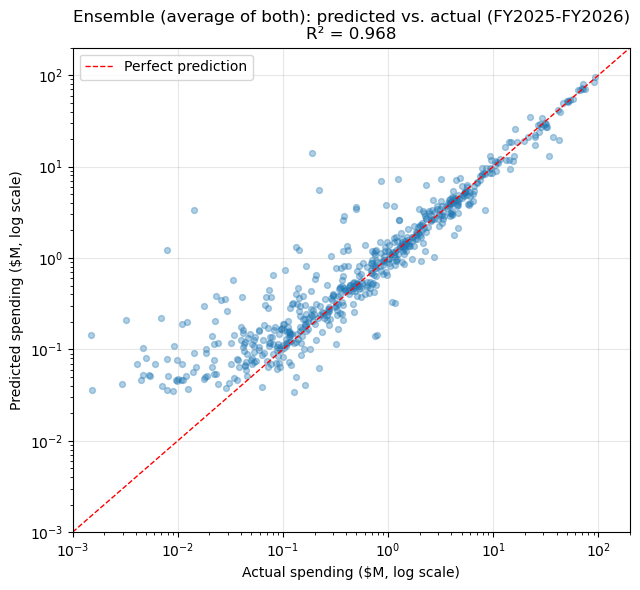

In [15]:
best_code_model = code_scores.drop(index="Baseline: spend the whole modified budget")["Accuracy_%"].idxmax()

plt.figure(figsize=(6.5, 6))
plt.scatter(test[TARGET] / M, predictions[best_code_model] / M, alpha=.35, s=18)
lims = [0.001, 200]
plt.plot(lims, lims, "r--", lw=1, label="Perfect prediction")
plt.xscale("log"); plt.yscale("log"); plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual spending ($M, log scale)"); plt.ylabel("Predicted spending ($M, log scale)")
plt.title(f"{best_code_model}: predicted vs. actual (FY2025-FY2026)\nR² = {code_scores.loc[best_code_model, 'R2']:.3f}")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 5. Accuracy table (all models)

In [16]:
accuracy_table = pd.DataFrame([
    {"Model": best_label, "Predicts": "Total agency spending per year",
     "Tested on": "FY2022-FY2026", "Error metric": "MAPE",
     "R2": arima_scores.loc[best_label, "R2"], "Error_%": arima_scores.loc[best_label, "MAPE_%"],
     "Accuracy_%": arima_scores.loc[best_label, "Accuracy_%"]},
    {"Model": f"{best_budget['Modified budget']} [modified budget]", "Predicts": "Total modified budget per year",
     "Tested on": "FY2022-FY2026", "Error metric": "MAPE",
     "R2": budget_scores.loc[("Modified budget", best_budget["Modified budget"]), "R2"],
     "Error_%": budget_scores.loc[("Modified budget", best_budget["Modified budget"]), "MAPE_%"],
     "Accuracy_%": budget_scores.loc[("Modified budget", best_budget["Modified budget"]), "Accuracy_%"]},
] + [
    {"Model": name, "Predicts": "Spending per budget code",
     "Tested on": "FY2025-FY2026", "Error metric": "WAPE",
     "R2": row["R2"], "Error_%": row["WAPE_%"], "Accuracy_%": row["Accuracy_%"]}
    for name, row in code_scores.iterrows()
]).set_index("Model")

accuracy_table.round(3)

,Predicts,Tested on,Error metric,R2,Error_%,Accuracy_%
Model,,,,,,
"ARIMAX(0,1,0) + adopted budget",Total agency spending per year,FY2022-FY2026,MAPE,0.681,3.164,96.836
Linear trend [modified budget],Total modified budget per year,FY2022-FY2026,MAPE,-0.025,4.209,95.791
Linear Regression,Spending per budget code,FY2025-FY2026,WAPE,0.957,19.167,80.833
Random Forest,Spending per budget code,FY2025-FY2026,WAPE,0.966,16.543,83.457
Ensemble (average of both),Spending per budget code,FY2025-FY2026,WAPE,0.968,16.497,83.503
Baseline: spend the whole modified budget,Spending per budget code,FY2025-FY2026,WAPE,0.922,30.587,69.413


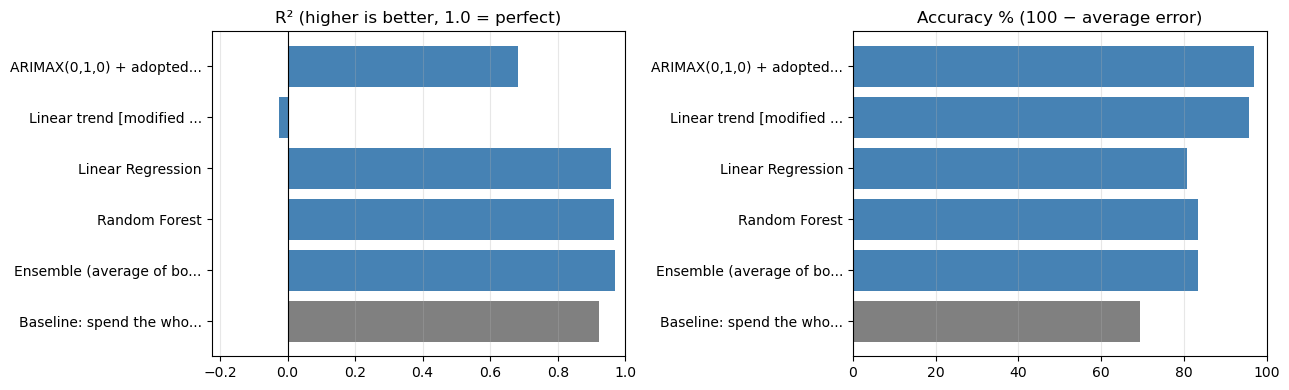

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
labels = [m if len(m) < 26 else m[:23] + "..." for m in accuracy_table.index]
colors = ["steelblue"] * (len(labels) - 1) + ["grey"]

ax[0].barh(labels, accuracy_table["R2"], color=colors)
ax[0].set_title("R² (higher is better, 1.0 = perfect)")
ax[0].set_xlim(min(0, accuracy_table["R2"].min() - 0.2), 1)
ax[0].axvline(0, color="black", lw=.8); ax[0].grid(alpha=.3, axis="x")
ax[1].barh(labels, accuracy_table["Accuracy_%"], color=colors)
ax[1].set_title("Accuracy % (100 − average error)"); ax[1].set_xlim(0, 100); ax[1].grid(alpha=.3, axis="x")
for a in ax:
    a.invert_yaxis()
plt.tight_layout(); plt.show()

## 6. Statistics

Everything a reader might ask for: how the data is distributed, whether the series is stationary,
which model terms are statistically significant, the full set of error measures, and which features
the code-level model actually relies on.

In [18]:
print("DESCRIPTIVE STATISTICS — agency totals per year, $ millions (FY2017-FY2026)")
display(yearly[["Adopted_Budget", "Modified_Budget", "Actual_Spending", "Utilization_%"]].describe().round(1))

growth = series.pct_change().dropna() * 100
print(f"Year-over-year growth in spending: mean {growth.mean():.2f}%, "
      f"std {growth.std():.2f}%, min {growth.min():.2f}%, max {growth.max():.2f}%")
print(f"Correlation between adopted budget and actual spending: {np.corrcoef(adopted, series)[0, 1]:.3f}")

DESCRIPTIVE STATISTICS — agency totals per year, $ millions (FY2017-FY2026)


,Adopted_Budget,Modified_Budget,Actual_Spending,Utilization_%
count,10.0,10.0,10.0,10.0
mean,1170.1,1212.1,1114.5,92.0
std,125.7,118.2,102.9,2.4
min,1006.1,1075.0,1001.0,88.1
25%,1064.8,1115.6,1032.3,90.2
50%,1205.3,1198.2,1084.4,92.2
75%,1246.3,1274.7,1179.1,93.3
max,1375.3,1447.5,1295.8,95.4


Year-over-year growth in spending: mean 2.76%, std 4.60%, min -6.55%, max 9.63%
Correlation between adopted budget and actual spending: 0.900


In [19]:
# Stationarity: an ARIMA with d=1 assumes the series needs one difference to become stationary.
for label, values in [("Spending level", series.values), ("Spending after differencing", np.diff(series.values))]:
    stat, pval = adfuller(values)[:2]
    verdict = "stationary" if pval < 0.05 else "NOT stationary"
    print(f"ADF test — {label:28s}: statistic {stat:6.3f}, p-value {pval:.3f}  ->  {verdict}")
print("\nThe level is not stationary but the differenced series is, which is why d=1 is the right choice.")

ADF test — Spending level              : statistic  0.328, p-value 0.979  ->  NOT stationary
ADF test — Spending after differencing : statistic -3.146, p-value 0.023  ->  stationary

The level is not stationary but the differenced series is, which is why d=1 is the right choice.


In [20]:
print(f"MODEL SUMMARY — {best_label}\n")
print(final_arima.summary())

MODEL SUMMARY — ARIMAX(0,1,0) + adopted budget

                               SARIMAX Results                                
Dep. Variable:        Actual_Spending   No. Observations:                   10
Model:                 ARIMA(0, 1, 0)   Log Likelihood                 -44.558
Date:                Mon, 10 Aug 2026   AIC                             95.115
Time:                        21:10:00   BIC                             95.707
Sample:                    01-01-2017   HQIC                            93.838
                         - 01-01-2026                                         
Covariance Type:                  opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
drift             18.9793     11.552      1.643      0.100      -3.663      41.621
Adopted_Budget     0.2835      0.128      2.217      0.027       0.033 

In [21]:
# Full error measures for both models on their test sets
def metrics(actual, pred, pct_name, pct_value):
    return {"R2": r2_score(actual, pred),
            "RMSE": np.sqrt(mean_squared_error(actual, pred)),
            "MAE": mean_absolute_error(actual, pred),
            pct_name: pct_value,
            "Accuracy_%": 100 - pct_value}

mape_best = arima_scores.loc[best_label, "MAPE_%"]
stats_arima = pd.DataFrame([metrics(actual_bt, pred_bt, "MAPE_%", mape_best)], index=[best_label])
print("Model 1 — agency totals (values in $ millions, tested on FY2022-FY2026)")
display(stats_arima.round(3))

stats_code = pd.DataFrame(
    [metrics(test[TARGET].values, p, "WAPE_%", wape(test[TARGET].values, p)) for p in predictions.values()],
    index=list(predictions.keys()))
stats_code[["RMSE", "MAE"]] = stats_code[["RMSE", "MAE"]] / M
print("Model 2 — budget codes (RMSE and MAE in $ millions, tested on FY2025-FY2026)")
display(stats_code.round(3))

Model 1 — agency totals (values in $ millions, tested on FY2022-FY2026)


,R2,RMSE,MAE,MAPE_%,Accuracy_%
"ARIMAX(0,1,0) + adopted budget",0.681,40.406,37.611,3.164,96.836


Model 2 — budget codes (RMSE and MAE in $ millions, tested on FY2025-FY2026)


,R2,RMSE,MAE,WAPE_%,Accuracy_%
Linear Regression,0.957,2.374,0.789,19.167,80.833
Random Forest,0.966,2.105,0.681,16.543,83.457
Ensemble (average of both),0.968,2.036,0.679,16.497,83.503
Baseline: spend the whole modified budget,0.922,3.188,1.259,30.587,69.413


In [22]:
importance = (pd.Series(rf.feature_importances_, index=FEATURES)
              .sort_values(ascending=False) * 100)
print("What the Random Forest relies on (% of total importance):")
for name, value in importance.items():
    print(f"  {name:20s} {value:5.1f}%")

coefs = pd.Series(lin.coef_, index=FEATURES).round(3)
print("\nLinear Regression coefficients (dollars of spending per dollar of feature):")
for name, value in coefs.items():
    print(f"  {name:20s} {value:+.3f}")

What the Random Forest relies on (% of total importance):
  Modified_Budget       58.9%
  Prev_Actual           20.0%
  Adopted_Budget        17.4%
  Prev_Modified          3.4%
  Post_Adjustments       0.3%
  Pre_Encumbered         0.0%

Linear Regression coefficients (dollars of spending per dollar of feature):
  Adopted_Budget       +0.109
  Modified_Budget      +0.828
  Prev_Actual          +0.713
  Prev_Modified        -0.662
  Post_Adjustments     -0.129
  Pre_Encumbered       +0.000


## 7. FY2027 prediction by budget code

In [ ]:
# Retrain the best code-level model on every year available, then predict FY2027
lin_full = LinearRegression().fit(panel[FEATURES], panel[TARGET])
rf_full = RandomForestRegressor(n_estimators=300, random_state=42).fit(panel[FEATURES], panel[TARGET])

prev = df[df["Year"] == 2026].set_index("Budget Code")
fy = fy2027.copy()
fy["Prev_Actual"] = fy["Budget Code"].map(prev["Actual_Spending"])
fy["Prev_Modified"] = fy["Budget Code"].map(prev["Modified_Budget"])
fy = fy.dropna(subset=["Prev_Actual"])
fy = fy[fy["Adopted_Budget"] > 0]

fy["Predicted_Spending"] = np.clip((lin_full.predict(fy[FEATURES]) + rf_full.predict(fy[FEATURES])) / 2, 0, None)
fy["Predicted_Use_%"] = fy["Predicted_Spending"] / fy["Adopted_Budget"] * 100
fy["Gap_$M"] = (fy["Adopted_Budget"] - fy["Predicted_Spending"]) / M

out = (fy.nlargest(15, "Adopted_Budget")
       .assign(Adopted_M=lambda d: d["Adopted_Budget"] / M,
               Predicted_M=lambda d: d["Predicted_Spending"] / M)
       [["Budget Code", "Code_Name", "Adopted_M", "Predicted_M", "Predicted_Use_%", "Gap_$M"]])
print("FY2027: the 15 largest budget codes, predicted spending vs. adopted budget")
out.round(1).reset_index(drop=True)

In [ ]:
# Funding recommendations, ranked by dollars rather than percentages
big = fy[fy["Adopted_Budget"] > 1e6]
under = big[big["Gap_$M"] < 0].nsmallest(10, "Gap_$M")
over = big.nlargest(10, "Gap_$M")

show = lambda d: (d.assign(Adopted_M=lambda x: x["Adopted_Budget"] / M,
                           Predicted_M=lambda x: x["Predicted_Spending"] / M)
                  [["Budget Code", "Code_Name", "Adopted_M", "Predicted_M", "Predicted_Use_%", "Gap_$M"]]
                  .round(1).reset_index(drop=True))

print("PRIORITY FOR MORE FUNDING — biggest predicted shortfalls, in dollars:")
display(show(under))
print("\nCANDIDATES FOR REALLOCATION — most money predicted to go unspent:")
display(show(over))
print("\nNote: some payroll codes get a small adopted budget and are topped up by mid-year transfers,")
print("so a very high predicted-use % can mean 'funded later' rather than 'underfunded'.")

PRIORITY FOR MORE FUNDING — biggest predicted shortfalls, in dollars:


,Budget Code,Code_Name,Adopted_M,Predicted_M,Predicted_Use_%,Gap_$M
0,2295,Full Year Positions (unnamed code),3.5,29.4,838.8,-25.9
1,2290,Executive Management,7.9,21.8,274.2,-13.8
2,2590,Overtime (unnamed code),3.5,15.3,441.9,-11.8
3,2891,Seasonal Positions (unnamed code),1.6,11.5,707.0,-9.9
4,2278,Full Year Positions (unnamed code),13.4,23.0,171.4,-9.6
5,2690,Tech Services Auto,8.0,14.1,176.4,-6.1
6,2790,Full Year Positions (unnamed code),26.2,31.2,118.7,-4.9
7,4990,Full Year Positions (unnamed code),12.8,17.1,133.6,-4.3
8,2287,Full Year Positions (unnamed code),9.8,13.9,142.4,-4.1
9,2280,Full Year Positions (unnamed code),2.5,6.2,247.0,-3.7



CANDIDATES FOR REALLOCATION — most money predicted to go unspent:


,Budget Code,Code_Name,Adopted_M,Predicted_M,Predicted_Use_%,Gap_$M
0,7000,Heat Light & Power (unnamed code),69.6,41.0,58.9,28.6
1,6809,Central Park Conservancy Contribution,27.5,8.8,32.1,18.7
2,P006,Rentals Of Misc.Equip (unnamed code),17.7,1.5,8.2,16.3
3,0110,Full Year Positions (unnamed code),75.8,62.8,82.9,13.0
4,2801,Seasonal Positions (unnamed code),106.6,96.0,90.1,10.6
5,6600,Forestry,20.8,10.3,49.5,10.5
6,6910,Tech Ser Vehicle Central,16.6,6.6,39.6,10.0
7,7800,Central Administration,16.2,6.8,42.2,9.4
8,6803,Parks Bridge Flag Repairs,9.7,1.8,19.1,7.8
9,HTS2,Full Year Positions (unnamed code),53.1,46.3,87.3,6.8



Note: some payroll codes get a small adopted budget and are topped up by mid-year transfers,
so a very high predicted-use % can mean 'funded later' rather than 'underfunded'.


## 8. Summary

In [ ]:
print("NYC PARKS — KEY FINDINGS (FY2017-FY2026)")
print("=" * 62)
print(f"Spending grew from ${series.iloc[0]:,.0f}M to ${series.iloc[-1]:,.0f}M "
      f"({(series.iloc[-1] / series.iloc[0] - 1) * 100:.0f}% over 10 years, "
      f"about {((series.iloc[-1] / series.iloc[0]) ** (1 / 9) - 1) * 100:.1f}% per year).")
print(f"Parks spends {yearly['Utilization_%'].mean():.1f}% of its modified budget on average, "
      f"leaving ${yearly['Unspent_$M'].mean():.0f}M unspent each year.")
print(f"FY2027 forecast: ${forecast.loc[0, 'Forecast_Spending_$M']:,.0f}M spending against a "
      f"${forecast.loc[0, 'Modified_Budget_$M']:,.0f}M modified budget "
      f"({forecast.loc[0, 'Predicted_Use_%']:.0f}% utilization).")
print()
print("MODEL ACCURACY")
print("=" * 62)
for name, row in accuracy_table.iterrows():
    print(f"{name:<45} R2 = {row['R2']:.3f}   Accuracy = {row['Accuracy_%']:.1f}%")
print()
print("Adding the adopted budget to the time-series model lifted R2 from "
      f"{arima_scores.loc['ARIMA(0,1,0) + drift', 'R2']:.3f} to {arima_scores.loc[best_label, 'R2']:.3f}.")
print("Both ML models beat the standard assumption that an agency spends its full modified budget "
      f"({accuracy_table.loc['Baseline: spend the whole modified budget', 'Accuracy_%']:.1f}% accurate).")

NYC PARKS — KEY FINDINGS (FY2017-FY2026)
Spending grew from $1,022M to $1,296M (27% over 10 years, about 2.7% per year).
Parks spends 92.0% of its modified budget on average, leaving $98M unspent each year.
FY2027 forecast: $1,327M spending against a $1,411M modified budget (94% utilization).

MODEL ACCURACY
ARIMAX(0,1,0) + adopted budget                R2 = 0.681   Accuracy = 96.8%
Linear trend [modified budget]                R2 = -0.025   Accuracy = 95.8%
Linear Regression                             R2 = 0.957   Accuracy = 80.8%
Random Forest                                 R2 = 0.966   Accuracy = 83.5%
Ensemble (average of both)                    R2 = 0.968   Accuracy = 83.5%
Baseline: spend the whole modified budget     R2 = 0.922   Accuracy = 69.4%

Adding the adopted budget to the time-series model lifted R2 from 0.469 to 0.681.
Both ML models beat the standard assumption that an agency spends its full modified budget (69.4% accurate).
